In [ ]:
%%capture

import time
import random
from copy import copy
import tqdm

try:
    from juliacall import Main as jl
except:
    !pip install juliacall
    from juliacall import Main as jl

try:
    import numpyro
except:
    !pip install numpyro
    import numpyro

numpyro.set_host_device_count(4)

import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, Predictive
import jax
import jax.numpy as jnp
import jax.scipy.stats as jstats
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import softmax

DEBUG_PRINTS = True

## LaserTag POMDP

The LaserTag POMDP problem is a classic Partially Observable Markov decision process that models a robot equipped with a laser sensor attempting to tag an opponent in a grid environment. This problem tests the robot's ability to track and intercept a moving target while dealing with noisy sensor observations.

#### Problem Description

- **States**:
  - The state space consists of the **robot's position**, the **opponent's position** on a grid, and a **terminal flag** indicating whether the game has ended. For example, a state might represent the robot at position `(x₁, y₁)`, the opponent at position `(x₂, y₂)`, and whether the episode is complete.

- **Actions**:
  - There are **4 basic movement actions**: north, south, east, west that move the robot one cell in the corresponding direction.
  - Additionally, there is a **tag action** that attempts to tag the opponent when they are in the same cell as the robot.
  - **Total**: 5 actions (4 movement + 1 tag).

- **Transition Model**:
  - **Robot movement**: The robot moves deterministically in the direction of the selected action. If the robot attempts to move into an obstacle or beyond the grid boundary, it remains in its current position.
  - **Opponent behavior**: The opponent moves according to a stochastic policy that attempts to avoid the robot. With 40% probability each, the opponent moves toward/away from the robot in the x and y directions, and with the remaining probability stays in place. The opponent cannot move through obstacles.
  - **Terminal condition**: The episode ends when the robot successfully tags the opponent (both occupy the same cell and tag action is executed).

- **Observation Model**:
  - The robot is equipped with a **laser sensor** that measures distances in **8 directions** (4 cardinal + 4 diagonal directions) from its current position.
  - Each laser measurement reports the **number of clear cells** until hitting an obstacle, wall, or the opponent.
  - The laser measurements are corrupted by **Gaussian noise** with standard deviation `std`. The noise follows a half-normal distribution (always reduces the measured distance).
  - The noise parameter `std` controls the **laser variance** - this is the key parameter we want to infer through Bayesian estimation.
  - When the robot and opponent are in the same location, a special observation is returned.

- **Reward Model**:
  - The robot incurs a **step cost** (negative reward) for every movement action.
  - **Successful tagging**: When the robot executes the tag action while in the same cell as the opponent, it receives a large **positive reward** (`tag_reward`).
  - **Failed tagging**: When the robot executes the tag action while not in the same cell as the opponent, it receives a large **negative penalty** (`-tag_reward`).
  - The step cost is applied regardless of the action type, encouraging the robot to complete the task quickly.

#### Objective

The goal is to **minimize the expected time to tag the opponent** while dealing with:
- **Partial observability**: The robot can only observe laser distance measurements, not the opponent's exact position.
- **Noisy observations**: The laser measurements contain noise, making it difficult to precisely locate the opponent.
- **Moving target**: The opponent actively tries to avoid being tagged, making the task more challenging.
- **Unknown noise level**: The true laser variance is unknown and must be inferred from interaction data.

The robot must balance exploration (gathering information about the opponent's location through laser measurements) with exploitation (moving toward the estimated opponent position for tagging). The uncertainty in laser measurements and the opponent's evasive behavior create a complex decision-making problem that requires sophisticated POMDP planning algorithms.

### Parameter Inference
In our Bayesian framework, we focus on inferring the **laser variance** parameter from observed robot-environment interactions, allowing for more accurate POMDP policies that properly account for sensor uncertainty.

# LaserTag POMDP: Bayesian Parameter Learning Case Study

## Objective

This experiment validates that Bayesian parameter inference can improve POMDP policy performance when model parameters are initially misspecified. We focus on learning the laser sensor noise parameter (laser_std) in the LaserTag environment, demonstrating the practical importance of accurate parameter specification for deployed POMDP systems.

## Experimental Setup

We use the LaserTag POMDP where a robot attempts to tag a moving opponent using noisy laser distance measurements. The key parameter is laser_std, which controls the Gaussian noise in sensor observations and significantly impacts the policy's belief state updates and decision-making.

The experiment follows a three-stage process. First, we generate a policy using an incorrect laser_std value and deploy it in the true environment, recording poor performance due to parameter misspecification. Second, we collect trajectory data from this deployment and use Bayesian inference to estimate the true laser_std parameter from the observed state-action-observation sequences. Third, we retrain the policy using the inferred parameter and demonstrate improved performance when deployed in the true environment.

## Hypothesis

A policy trained with incorrect sensor noise parameters will perform poorly in the true environment, but retraining with Bayesian-inferred parameters will recover most of the performance loss compared to an oracle policy trained with true parameters.

## Evaluation Metrics

We measure performance recovery as (Reward_improved - Reward_wrong) / (Reward_oracle - Reward_wrong), parameter estimation accuracy as the relative error between inferred and true values, and statistical significance across multiple experimental runs. Success is demonstrated by significant performance improvement and accurate parameter recovery using realistic amounts of interaction data.

## Implementation

The framework integrates JuliaPOMDP for policy generation, juliacall for Julia-Python interoperability in Colab, and NumPyro for Bayesian inference. We implement a generative model $P(\text{observations | laser_std, states, actions})$ that captures the sensor noise process, then use MCMC sampling to estimate the posterior distribution over laser_std given observed trajectory data.

In [ ]:
# Install required Julia packages
jl.Pkg.add('POMDPs')
jl.Pkg.add(url="https://github.com/JuliaPOMDP/LaserTag.jl.git")
jl.Pkg.add('QMDP')
jl.Pkg.add('POMDPTools')
jl.Pkg.add('ParticleFilters')

print("Julia packages installed successfully!")

Julia packages installed successfully!


## Policy Generation Function

This function creates a QMDP policy for the LaserTag environment with a specified laser sensor noise parameter (laser_std). This allows us to train policies with different assumptions about sensor accuracy.

In [ ]:
def generate_policy(pomdp):
    """Generate a QMDP policy for given LaserTag POMDP"""
    if DEBUG_PRINTS:
        print("Generating policy for provided POMDP...")

    try:
        jl.training_pomdp = pomdp

        jl.seval(f"""
        using POMDPs, QMDP

        # Solve with QMDP on the provided POMDP
        solver = QMDPSolver(verbose=false)
        policy = solve(solver, training_pomdp)
        """)

        return jl.policy

    except Exception as e:
        if DEBUG_PRINTS:
            print(f"Policy generation failed: {e}")
        return None

In [ ]:
def create_pomdp_environment(laser_std, random_seed=123):
    """Create LaserTag POMDP environment with specified laser_std"""
    if DEBUG_PRINTS:
        print(f"Creating environment with laser_std={laser_std}...")

    try:
        jl.seval(f"""
        using POMDPs, LaserTag, Random

        # Set random seed for deterministic environment creation
        Random.seed!({random_seed})

        obs_model = LaserTag.DESPOTEmu(LaserTag.Floor(7, 11), {laser_std})
        pomdp_env = gen_lasertag(7, 11,
                                obstacles=Set{{LaserTag.Coord}}(),
                                obs_model=obs_model,
                                robot_position_known=true)
        """)

        print("Environment created successfully")
        return jl.pomdp_env

    except Exception as e:
        if DEBUG_PRINTS:
            print(f"Environment creation failed: {e}")
        return None

## Policy Testing Function

This function tests a policy in an environment with the TRUE laser_std parameter, simulating real-world deployment. It collects trajectory data (states, actions, observations, rewards) that we'll use for Bayesian inference.

In [ ]:
def test_policy(policy, pomdp, belief_pomdp=None, n_episodes=10, max_steps=100, random_seed=1000):
    """
    Test a policy on true environment with belief updates

    Args:
        policy: The policy to test
        pomdp: The TRUE environment to test in
        belief_pomdp: The POMDP model used for belief updates (if None, uses true environment)
        n_episodes: Number of episodes
        max_steps: Max steps per episode
        random_seed: Base random seed - each episode uses random_seed + episode_number
    """
    if DEBUG_PRINTS:
        print(f"Testing policy for {n_episodes} episodes...")

    try:
        jl.test_policy = policy
        jl.true_env_pomdp = pomdp  # true environment for simulation
        jl.belief_pomdp = belief_pomdp if belief_pomdp is not None else pomdp  # model for beliefs
        jl.n_eps = n_episodes
        jl.max_steps = max_steps
        jl.base_seed = random_seed

        jl.seval(f"""
        using POMDPs, POMDPTools, ParticleFilters, Statistics, Random

        episode_rewards = Float64[]
        all_trajectories = []

        # Create particle filter for belief updates
        updater = BootstrapFilter(belief_pomdp, 10000)

        for ep in 1:n_eps
            # Set different seed for each episode: base_seed + episode_number
            episode_seed = base_seed + ep - 1
            Random.seed!(episode_seed)

            # Initialize from TRUE environment
            s = rand(initialstate(true_env_pomdp))

            # Initialize belief using the belief model (potentially wrong model)
            b0 = initialstate(belief_pomdp)
            b = initialize_belief(updater, b0)

            episode_reward = 0.0
            step = 0

            traj_states = []
            traj_actions = []
            traj_observations = []
            traj_rewards = []

            while !isterminal(true_env_pomdp, s) && step < max_steps
                # Get action based on (potentially wrong) beliefs
                a = action(test_policy, b)

                # Generate observation from TRUE environment
                sp, o, r = @gen(:sp, :o, :r)(true_env_pomdp, s, a)

                # Update belief using the belief model (which may be wrong!)
                try
                    b = update(updater, b, a, o)
                catch e
                    # If update fails, just keep previous belief
                    # This handles terminal particle issues more gracefully
                end

                push!(traj_states, s)
                push!(traj_actions, a)
                push!(traj_observations, o)
                push!(traj_rewards, r)

                episode_reward += r
                s = sp
                step += 1
            end

            push!(episode_rewards, episode_reward)
            push!(all_trajectories, Dict(
                "states" => traj_states,
                "actions" => traj_actions,
                "observations" => traj_observations,
                "rewards" => traj_rewards
            ))
        end
        """)

        return jl.all_trajectories

    except Exception as e:
        if DEBUG_PRINTS:
            print(f"Policy testing failed: {e}")
        return None

## Validation: Smoke Test

Before proceeding with Bayesian inference, let's validate our experimental setup by comparing two policies: one trained with wrong parameters and one trained with correct parameters. Both will be tested in the true environment. This "smoke test" confirms that parameter misspecification actually hurts performance, validating the foundation of our experiment.

In [ ]:
DEBUG_PRINTS = False

print("---- Creating environments... ----")
sim_pomdp = create_pomdp_environment(laser_std=10.0, random_seed=123)  # Incorrect training environment
real_pomdp = create_pomdp_environment(laser_std=2.5, random_seed=123)  # True real-world environment

print("---- Generating policies... ----")
sim_policy = generate_policy(sim_pomdp)    # Train on incorrect environment
real_policy = generate_policy(real_pomdp)  # Train on correct environment

print("---- Testing policies... ----")
print("Testing wrong policy...")
sim_trajectories = test_policy(
    sim_policy,
    pomdp=real_pomdp,
    belief_pomdp=sim_pomdp,
    n_episodes=1000,
    random_seed=7)

print("Testing correct policy...")
real_trajectories = test_policy(
    real_policy,
    pomdp=real_pomdp,
    belief_pomdp=real_pomdp,
    n_episodes=1000,
    random_seed=7)

---- Creating environments... ----
Environment created successfully
Environment created successfully
---- Generating policies... ----
---- Testing policies... ----
Testing wrong policy...
Testing correct policy...


/tmp/ipython-input-3646929549.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=labels, patch_artist=True,


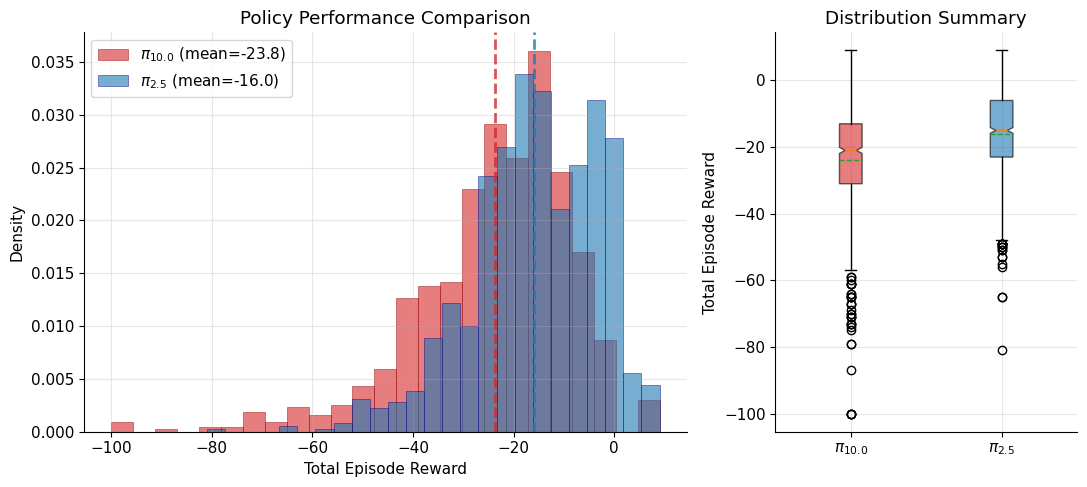

POLICY EVALUATION RESULTS
Episodes per policy: 1,000

π₁₀.₀:
  Mean reward: -23.76 ± 15.52
  Median reward: -21.00

π₂.₅:
  Mean reward: -15.99 ± 12.60
  Median reward: -15.00

Performance Gap:
  Difference: 7.77 (+32.7%)


In [ ]:
sim_rewards = [sum(ep['rewards']) for ep in sim_trajectories if ep is not None]
real_rewards = [sum(ep['rewards']) for ep in real_trajectories if ep is not None]

plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [2.0, 1.0]})

sim_rewards_np = np.array(sim_rewards)
real_rewards_np = np.array(real_rewards)
sim_mean, sim_std = np.mean(sim_rewards_np), np.std(sim_rewards_np)
real_mean, real_std = np.mean(real_rewards_np), np.std(real_rewards_np)

# Left plot: Updated labels with LaTeX notation
ax1.hist(sim_rewards_np, bins=25, alpha=0.6, density=True,
         label=rf'$\pi_{{10.0}}$ (mean={sim_mean:.1f})',
         color='#d62728', edgecolor='darkred', linewidth=0.5)
ax1.hist(real_rewards_np, bins=25, alpha=0.6, density=True,
         label=rf'$\pi_{{2.5}}$ (mean={real_mean:.1f})',
         color='#1f77b4', edgecolor='darkblue', linewidth=0.5)

ax1.axvline(sim_mean, color='#d62728', linewidth=2, linestyle='--', alpha=0.8)
ax1.axvline(real_mean, color='#1f77b4', linewidth=2, linestyle='--', alpha=0.8)

ax1.set_xlabel('Total Episode Reward')
ax1.set_ylabel('Density')
ax1.set_title('Policy Performance Comparison')
ax1.legend(loc='best')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right plot: Clean LaTeX labels
box_data = [sim_rewards_np, real_rewards_np]
labels = [r'$\pi_{10.0}$', r'$\pi_{2.5}$']

bp = ax2.boxplot(box_data, labels=labels, patch_artist=True,
                 notch=True, showmeans=True, meanline=True)

bp['boxes'][0].set_facecolor('#d62728')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#1f77b4')
bp['boxes'][1].set_alpha(0.6)

ax2.set_ylabel('Total Episode Reward')
ax2.set_title('Distribution Summary')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("=" * 50)
print("POLICY EVALUATION RESULTS")
print("=" * 50)
print(f"Episodes per policy: {len(sim_rewards_np):,}")
print(f"\nπ₁₀.₀:")
print(f"  Mean reward: {sim_mean:.2f} ± {sim_std:.2f}")
print(f"  Median reward: {np.median(sim_rewards_np):.2f}")
print(f"\nπ₂.₅:")
print(f"  Mean reward: {real_mean:.2f} ± {real_std:.2f}")
print(f"  Median reward: {np.median(real_rewards_np):.2f}")
print(f"\nPerformance Gap:")
print(f"  Difference: {real_mean - sim_mean:.2f} ({((real_mean - sim_mean)/abs(sim_mean)*100):+.1f}%)")
print("=" * 50)

In [ ]:
def extract_trajectories_data(trajectories, pomdp):
    """
    Extract trajectory data with correct temporal alignment

    Trajectory collection produces:
    - states[i] = state at time i
    - observations[i] = observation of states[i+1]

    We align by keeping all states and using None for missing observations:
    - states[0] with observations[0] = None (no observation of initial state)
    - states[i] with observations[i-1] for i > 0
    """

    # extract obstacles from the provided POMDP
    jl.temp_pomdp = pomdp
    jl.seval("obstacles_list = collect(temp_pomdp.obstacles)")
    obstacles = [(int(obs[0]), int(obs[1])) for obs in jl.obstacles_list]

    episodes = []

    # extract data from each trajectory (each trajectory = one episode)
    for traj_idx, traj in enumerate(trajectories):
        traj_dict = dict(traj)

        states = traj_dict['states']
        actions = traj_dict['actions']
        observations = traj_dict['observations']
        rewards = traj_dict['rewards']

        episode_observations = []
        episode_states = []
        episode_actions = []
        episode_rewards = []

        for step in range(len(states)):
            # Parse current state
            state = states[step]
            robot_pos = (int(state.robot[0]), int(state.robot[1]))
            opponent_pos = (int(state.opponent[0]), int(state.opponent[1]))
            terminal = bool(state.terminal)
            parsed_state = (robot_pos, opponent_pos, terminal)

            episode_states.append(parsed_state)

            # align observations: obs[i-1] corresponds to states[i]
            if step == 0:
                # None observation for initial state
                episode_observations.append(None)
            else:
                # observations[step-1] is the observation OF states[step]
                episode_observations.append(list(observations[step - 1]))

            if step < len(actions):
                episode_actions.append(actions[step])
            if step < len(rewards):
                episode_rewards.append(rewards[step])

        episodes.append({
            'observations': episode_observations,  # Contains None for first element
            'states': episode_states,
            'actions': episode_actions,
            'rewards': episode_rewards
        })

    inference_data = {
        'episodes': episodes,
        'obstacles': obstacles,
        'n_episodes': len(episodes),
        'n_total_steps': sum(len(ep['observations']) for ep in episodes)
    }

    return inference_data

In [ ]:
N_DATA = 15

data = extract_trajectories_data(sim_trajectories[:N_DATA], real_pomdp)

print(f"Extracted data:")
print(f"  Number of episodes: {data['n_episodes']}")
print(f"  Total steps across all episodes: {data['n_total_steps']}")
print(f"  Episode 0 length: {len(data['episodes'][0]['observations'])}")
print(f"  Sample state from episode 0: {data['episodes'][0]['states'][0]}")
print(f"  Sample observation from episode 0: {data['episodes'][0]['observations'][0]}")
print(f"  Obstacles: {data['obstacles']}")

Extracted data:
  Number of episodes: 15
  Total steps across all episodes: 374
  Episode 0 length: 26
  Sample state from episode 0: ((6, 5), (3, 6), False)
  Sample observation from episode 0: None
  Obstacles: []


## Data Format

**POMDP Trajectory Structure:**

A POMDP trajectory consists of sequences $(s_t, a_t, o_t, r_t)_{t=0}^T$ where:
- $s_t \in S$ = state at time $t$
- $a_t \in A$ = action taken at time $t$
- $o_t \in O$ = observation received at time $t$
- $r_t \in R$ = reward received at time $t$

**Temporal Causality:**

The standard POMDP generative process follows:
$$s_0 \xrightarrow{a_0} s_1 \xrightarrow{a_1} s_2 \xrightarrow{a_2} s_3 \xrightarrow{a_3} \cdots$$

With observations generated as:
$$o_t \sim O(s_{t+1}) \quad \text{where } o_t \text{ is observed after transitioning to } s_{t+1}$$

**Data Alignment:**

Trajectory collection via `@gen(:sp, :o, :r)` produces:
- `states = [s₀, s₁, s₂, s₃, s₄]`
- `observations = [o₀, o₁, o₂, o₃]` where $o_i$ is the observation of $s_{i+1}$

**Correct Temporal Alignment:**

To ensure $\text{observations}[i]$ corresponds to $\text{states}[i]$:

```
states[0] = s₀  →  observations[0] = None     (no observation of initial state)
states[1] = s₁  →  observations[1] = o₀       (o₀ is observation of s₁)  
states[2] = s₂  →  observations[2] = o₁       (o₁ is observation of s₂)
states[3] = s₃  →  observations[3] = o₂       (o₂ is observation of s₃)
states[4] = s₄  →  observations[4] = o₃       (o₃ is observation of s₄)
```

**Likelihood Calculation:**

For parameter inference, we skip entries where `observations[i] is None`:

$$L(\theta) = \prod_{\substack{i=1 \\ \text{obs}[i] \neq \text{None}}}^{T} p(\text{observations}[i] | \text{states}[i], \theta)$$

Where $p(\text{observations}[i] | \text{states}[i], \theta)$ represents the LaserTag observation model with parameter $\theta$ (laser noise standard deviation), evaluated at the state-observation pair.

In [ ]:
def logprob_laser_episode(laser_std, episode_states, episode_observations):
    """
    LaserTag logprob calculation per episode.
    observed <= true_distance always, with abs_noise ~ HalfNormal(laser_std)
    """
    directions = [(0, 1), (1, 0), (0, -1), (-1, 0), (1, 1), (1, -1), (-1, -1), (-1, 1)]

    # collect all data for vectorized computation
    all_true_distances = []
    all_observed = []
    grid = (11, 7)

    for step in range(len(episode_states)):
        robot_pos, opponent_pos, terminal = episode_states[step]
        if terminal:
            break

        observed_distances = episode_observations[step]

        if robot_pos == opponent_pos:
            continue

        if observed_distances is None or np.any(np.array(observed_distances) < 0):
            continue

        for direction_idx, (dx, dy) in enumerate(directions):
            # Calculate clear cells
            distance = 0
            x, y = robot_pos
            while True:
                x += dx
                y += dy
                distance += 1
                if x < 1 or x > grid[0] or y < 1 or y > grid[1]:
                    break
                if (x, y) == opponent_pos:
                    break

            clear_cells = distance - 1
            observed_distance = observed_distances[direction_idx]

            # Calculate "true processed distance" as in LaserTag
            if direction_idx < 4:  # Cardinal
                true_distance = clear_cells + 1
            else:  # in the diagonal, we talk the Euclidean distance, which is (true_distance + 1) * sqrt(2) (assuming a cell has has size 1x1, the diagonal length is sqrt(2))
                true_distance = (clear_cells + 1) * jnp.sqrt(2)

            all_true_distances.append(true_distance)
            all_observed.append(observed_distance)

    all_true_distances = jnp.array(all_true_distances)
    all_observed = jnp.array(all_observed)

    # abs_noise ~ HalfNormal(laser_std)
    # abs_noise = true_distance - observed
    abs_noise_values = all_true_distances - all_observed

    # calculate log probability using HalfNormal distribution
    half_normal_logprobs = dist.HalfNormal(laser_std).log_prob(abs_noise_values)
    total_logp = jnp.sum(half_normal_logprobs)

    return total_logp

def model(data):
    """Bayesian model for laser_std inference"""
    laser_std = numpyro.sample('laser_std', dist.Exponential(0.2))

    for iepisode, episode in enumerate(data['episodes']):
        states = episode['states']
        observations = episode['observations']
        episode_logp = logprob_laser_episode(laser_std, states, observations)
        numpyro.factor(f'episode_{iepisode}', episode_logp)

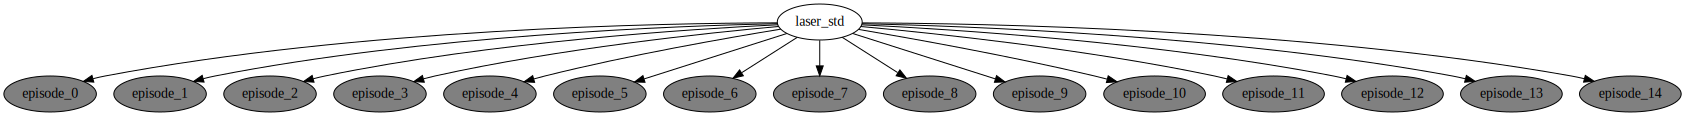

In [ ]:
numpyro.render_model(model, model_args=(data,))

In [ ]:
def run_inference(model, data, num_warmup=1000, num_samples=5000):
    nuts_kernel = NUTS(model)
    mcmc = MCMC(nuts_kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=4)

    rng_key = jax.random.PRNGKey(3)
    mcmc.run(rng_key, data)

    return mcmc

In [ ]:
mcmc = run_inference(model, data)
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  laser_std      2.47      0.03      2.47      2.41      2.52   6371.31      1.00

Number of divergences: 0


In [ ]:
def plot_inference_results(mcmc, actual_laser_std=2.5):
    samples = mcmc.get_samples()
    laser_std_samples = samples['laser_std']

    plt.figure(figsize=(10, 4))

    # posterior
    plt.subplot(1, 2, 1)
    # plt.hist(stats.lognorm(s=1.0, loc=0.5).rvs(10000), bins='auto', alpha=0.7)
    plt.hist(laser_std_samples, bins='auto', alpha=0.7, density=True)
    plt.axvline(actual_laser_std, color='red', label=f'actual laser_std: {actual_laser_std}')
    plt.axvline(np.mean(laser_std_samples), color='green', label=f'MCMC Mean: {np.mean(laser_std_samples):.2f}')
    plt.xlabel('laser_std')
    plt.title('Posterior')
    plt.legend()

    # trace plot
    plt.subplot(1, 2, 2)
    plt.plot(laser_std_samples)
    plt.axhline(actual_laser_std, color='red', label=f'actual laser_std: {actual_laser_std}')
    plt.xlabel('Sample')
    plt.title('Trace')
    plt.legend()

    plt.tight_layout()
    plt.show()

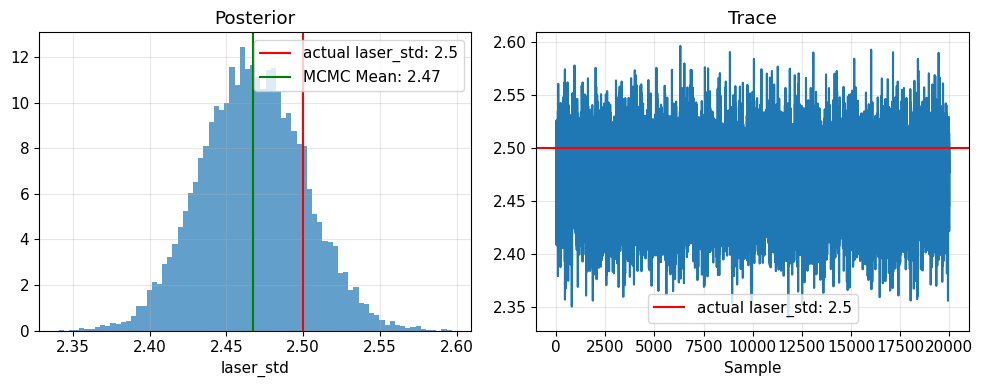

In [ ]:
plot_inference_results(mcmc, actual_laser_std=2.5)

# LaserTag SVI: Learning Sensor Parameters with Unknown Robot Positions

In the JuliaPOMDP LaserTag framework, we don't have access to modify the transition model to add stochasticity. However, we have laser distance observations that were recorded along with robot positions during deterministic episodes.

To test our SVI POMDP parameter learning algorithm, we want to "discard" the robot positions from the observations and learn the sensor noise parameter (`laser_std`) using only the laser measurements. We'll use a stochastic transition model to generate possible robot trajectories.

**Why this approach is theoretically correct:** Even though the original data came from deterministic movements, we can treat the robot positions as hidden states and use Bayesian inference to simultaneously estimate both the unknown trajectories and the sensor parameter. **The stochastic model represents our uncertainty about the robot's path, not the actual randomness that occurred.** The laser observations constrain which robot trajectories are more probable - trajectories that better explain the observed laser distances will get higher likelihood scores.

Through SVI, we'll sample many possible trajectories and let the laser observations tell us which ones (and which laser_std values) best explain the data.

## Removing Robot Positions from Observations

Since we want to test learning without knowing robot positions, we need to create a modified version of our data that only contains the laser distance measurements. We'll keep everything else (opponent positions, actions, rewards) but remove the robot positions from the state information.

This simulates a realistic scenario where we have sensor data and know our actions, but don't have perfect localization of our robot.

In [ ]:
def remove_opponent_positions(data):
    """Remove opponent positions from episodes (but keep robot positions)"""
    modified_episodes = []

    for episode in data['episodes']:
        modified_states = []

        for i, state in enumerate(episode['states']):
            robot_pos, opponent_pos, terminal = state
            if i == 0:
                # Keep initial opponent position - we need to know where they start
                modified_state = (robot_pos, opponent_pos, terminal)
            else:
                # Remove opponent position from subsequent states - this is what we'll infer
                modified_state = (robot_pos, None, terminal)
            modified_states.append(modified_state)

        modified_episode = {
            'observations': episode['observations'],  # Keep laser measurements
            'states': modified_states,                # Robot positions kept, opponent removed
            'actions': episode['actions'],            # Keep actions
            'rewards': episode['rewards']             # Keep rewards
        }
        modified_episodes.append(modified_episode)

    return {
        'episodes': modified_episodes,
        'obstacles': data['obstacles'],
        'n_episodes': data['n_episodes'],
        'n_total_steps': data['n_total_steps']
    }

## Stochastic Transition Model

Since we don't know where the robot actually moved, we'll use a stochastic transition model to generate possible robot trajectories. We'll assume 80% chance the robot moves in the intended direction, and 10% chance for each perpendicular direction.

**The stochastic model represents our uncertainty about the robot's path, not the actual randomness that occurred.** We'll generate many possible trajectories and let the laser observations tell us which ones are more likely.

In [ ]:
def apply_stochastic_opponent_movement(robot_pos, prev_opponent_pos, obstacles=None):
    """
    Apply stochastic opponent movement based on LaserTag Julia implementation.

    Opponent behavior (AVOIDANCE):
    - 0.4 chance of moving away from robot in x direction (if not blocked)
    - 0.4 chance of moving away from robot in y direction (if not blocked)
    - 0.2 + blocked mass chance of staying in place
    """
    if obstacles is None:
        obstacles = set()

    # Grid boundaries
    grid_bounds = (11, 7)  # (width, height)

    # Cardinal directions: north, east, south, west
    cardinal_dirs = [(0, 1), (1, 0), (0, -1), (-1, 0)]

    # Initialize movement probabilities [north, east, south, west, stay]
    probs = [0.0, 0.0, 0.0, 0.0, 0.0]

    robot_x, robot_y = robot_pos
    opp_x, opp_y = prev_opponent_pos

    # 0.4 chance of moving in x direction (AVOIDANCE behavior - move away from robot)
    if opp_x == robot_x:
        # Equal distance, split probability
        # Check east (direction index 1)
        new_pos_east = (opp_x + 1, opp_y)
        if (new_pos_east[0] >= 1 and new_pos_east[0] <= grid_bounds[0] and
            new_pos_east[1] >= 1 and new_pos_east[1] <= grid_bounds[1] and
            new_pos_east not in obstacles):
            probs[1] += 0.2  # east

        # Check west (direction index 3)
        new_pos_west = (opp_x - 1, opp_y)
        if (new_pos_west[0] >= 1 and new_pos_west[0] <= grid_bounds[0] and
            new_pos_west[1] >= 1 and new_pos_west[1] <= grid_bounds[1] and
            new_pos_west not in obstacles):
            probs[3] += 0.2  # west

    elif opp_x > robot_x:
        # Move east away from robot (direction index 1)
        new_pos_east = (opp_x + 1, opp_y)
        if (new_pos_east[0] >= 1 and new_pos_east[0] <= grid_bounds[0] and
            new_pos_east[1] >= 1 and new_pos_east[1] <= grid_bounds[1] and
            new_pos_east not in obstacles):
            probs[1] += 0.4  # east

    elif opp_x < robot_x:
        # Move west away from robot (direction index 3)
        new_pos_west = (opp_x - 1, opp_y)
        if (new_pos_west[0] >= 1 and new_pos_west[0] <= grid_bounds[0] and
            new_pos_west[1] >= 1 and new_pos_west[1] <= grid_bounds[1] and
            new_pos_west not in obstacles):
            probs[3] += 0.4  # west

    # 0.4 chance of moving in y direction (AVOIDANCE behavior - move away from robot)
    if opp_y == robot_y:
        # Equal distance, split probability
        # Check north (direction index 0)
        new_pos_north = (opp_x, opp_y + 1)
        if (new_pos_north[0] >= 1 and new_pos_north[0] <= grid_bounds[0] and
            new_pos_north[1] >= 1 and new_pos_north[1] <= grid_bounds[1] and
            new_pos_north not in obstacles):
            probs[0] += 0.2  # north

        # Check south (direction index 2)
        new_pos_south = (opp_x, opp_y - 1)
        if (new_pos_south[0] >= 1 and new_pos_south[0] <= grid_bounds[0] and
            new_pos_south[1] >= 1 and new_pos_south[1] <= grid_bounds[1] and
            new_pos_south not in obstacles):
            probs[2] += 0.2  # south

    elif opp_y > robot_y:
        # Move north away from robot (direction index 0)
        new_pos_north = (opp_x, opp_y + 1)
        if (new_pos_north[0] >= 1 and new_pos_north[0] <= grid_bounds[0] and
            new_pos_north[1] >= 1 and new_pos_north[1] <= grid_bounds[1] and
            new_pos_north not in obstacles):
            probs[0] += 0.4  # north

    elif opp_y < robot_y:
        # Move south away from robot (direction index 2)
        new_pos_south = (opp_x, opp_y - 1)
        if (new_pos_south[0] >= 1 and new_pos_south[0] <= grid_bounds[0] and
            new_pos_south[1] >= 1 and new_pos_south[1] <= grid_bounds[1] and
            new_pos_south not in obstacles):
            probs[2] += 0.4  # south

    # Remaining probability goes to staying in place
    probs[4] = 1.0 - sum(probs[:4])

    # Sample movement based on probabilities using standard random
    choice_int = np.random.choice(5, p=probs)

    if choice_int == 4:  # stay in place
        return prev_opponent_pos
    else:
        # Move in chosen direction
        dx, dy = cardinal_dirs[choice_int]
        new_pos = (opp_x + dx, opp_y + dy)
        return new_pos

## Trajectory Generation

For each episode, we need to generate possible **complete state trajectories** (both robot and opponent positions) using our stochastic models. We'll take the initial positions and the sequence of actions, then simulate where both the robot and opponent might have actually moved.
**Robot movement**: Using our stochastic model with configurable success probability (e.g., 90% intended direction, 5% each perpendicular direction)

**Opponent movement**: Using the LaserTag transition model (40% toward robot in x-direction, 40% toward robot in y-direction, 20% staying in place)

This approach is crucial for **avoiding parameter bias.** When robot positions are different from the original data due to stochastic movement, the opponent positions must also be allowed to vary. Otherwise, the likelihood computation uses wrong robot-opponent distances, and the laser_std parameter gets inflated to compensate for these geometric errors.

We generate new complete trajectories each SVI step to explore different possibilities - this is key to avoiding gradient cancellation while maintaining the correct parameter relationships.

In [ ]:
def generate_trajectories(data):
    """
    Generate opponent trajectory realizations for all episodes.
    Robot positions are known (from data), opponent positions are sampled.
    """
    trajectories = []
    obstacles = set(data['obstacles'])

    for episode in data['episodes']:
        # Get initial positions from first state
        initial_robot_pos, initial_opponent_pos, _ = episode['states'][0]

        # The trajectory starts with the first state from the data
        trajectory = [episode['states'][0]]

        # Track current opponent position (robot positions come from data)
        current_opponent_pos = initial_opponent_pos

        for i in range(len(episode['states']) - 1):
            # Get robot position from original data (this is known)
            robot_pos = episode['states'][i + 1][0]
            terminal = episode['states'][i + 1][2]

            if not terminal:
                # Sample opponent movement based on robot position
                current_opponent_pos = apply_stochastic_opponent_movement(
                    robot_pos=robot_pos,
                    prev_opponent_pos=current_opponent_pos,
                    obstacles=obstacles
                )

            # Append new state with known robot position and sampled opponent position
            trajectory.append((robot_pos, current_opponent_pos, terminal))

        trajectories.append(trajectory)

    return trajectories

## SVI Model and Guide

Now we define the NumPyro model that samples the `laser_std` parameter and scores trajectories, plus the variational guide for SVI optimization.

In [ ]:
def guide(data, trajectories):
    # Normal guide - optimize mean and std
    mu = numpyro.param('laser_std_mean', 5.0, constraint=dist.constraints.positive)
    sigma = numpyro.param('laser_std_std', 1.0, constraint=dist.constraints.positive)
    numpyro.sample('laser_std', dist.Normal(mu, sigma))

In [ ]:
def laser_model_svi(data, trajectories):
    laser_std = numpyro.sample("laser_std", dist.Exponential(0.2))

    for iepisode, (episode, traj) in enumerate(zip(data['episodes'], trajectories)):
        states = episode['states']
        observations = episode['observations']
        episode_logp = logprob_laser_episode(laser_std, traj, episode['observations'])
        numpyro.factor(f'episode_{iepisode}', episode_logp)

## Running SVI Inference

Finally, we put everything together. Each SVI step, we generate new stochastic trajectories and update our parameter estimates. This is the key to avoiding gradient cancellation - by generating different possible robot paths each step, we explore the space of trajectories and let the laser observations guide us to the right parameter values.

In [ ]:
def svi_inference(data, model, num_steps=500):
    print("Running SVI inference...")

    optimizer = numpyro.optim.Adam(step_size=0.01)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO(num_particles=1000))

    rng_key = jax.random.PRNGKey(int(time.time() * 1E6))

    # init with first trajectories
    init_traj = generate_trajectories(data)
    svi_state = svi.init(rng_key, data, init_traj)

    losses0 = jnp.zeros(num_steps)
    means0  = jnp.zeros(num_steps)

    def body_fn(i, carry):
        svi_state, losses, means = carry

        # regenerate trajectories (still Python, unchanged)
        trajectories = generate_trajectories(data)

        svi_state, loss = svi.update(svi_state, data, trajectories)
        params = svi.get_params(svi_state)
        mean_val = params['laser_std_mean']

        losses = losses.at[i].set(loss)
        means  = means.at[i].set(mean_val)

        return svi_state, losses, means

    svi_state, losses, means = jax.lax.fori_loop(
        0, num_steps, body_fn, (svi_state, losses0, means0)
    )

    params = svi.get_params(svi_state)
    return list(np.array(losses)), list(np.array(means)), params


In [ ]:
data_no_opponent = remove_opponent_positions(data)

In [ ]:
# Run SVI inference without robot positions
svi_losses, svi_means, svi_params = svi_inference(data_no_opponent, laser_model_svi, num_steps=2000)

Running SVI inference...


In [ ]:
def plot_svi_inference(losses, means, final_params=None, actual_laser_std=2.5):
    fig, ax = plt.subplots(2, 1)

    # Plot mean laser_std convergence
    ax[0].plot(means)
    ax[0].axhline(y=actual_laser_std, ls='dashed', color='red', label=f'Actual laser_std ({actual_laser_std})')
    ax[0].set_xlabel("Step")
    ax[0].set_ylabel("Mean laser_std")
    ax[0].set_title("Learned Laser Standard Deviation")
    ax[0].set_ylim(actual_laser_std-0.5)
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Plot posterior comparison
    if final_params is not None:
        # Generate samples from SVI posterior for histogram
        mean_svi = final_params['laser_std_mean'].item()
        std_svi = final_params['laser_std_std'].item()
        svi_samples = np.random.normal(mean_svi, std_svi, 40000)

        # Both as histograms
        ax[1].hist(svi_samples, bins='auto', density=True, alpha=0.7, color='green',
                  label='SVI', linewidth=0.5)

        ax[1].axvline(actual_laser_std, color='red', linestyle=':', label=f'Actual ({actual_laser_std})')
        ax[1].axvline(means[-1], linestyle=':', label=f'Inferred Mean ({means[-1]:.2f})')

        ax[1].set_xlabel("laser_std")
        ax[1].set_ylabel("Posterior Density")
        ax[1].set_title("SVI Posterior")
        ax[1].legend()
        ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

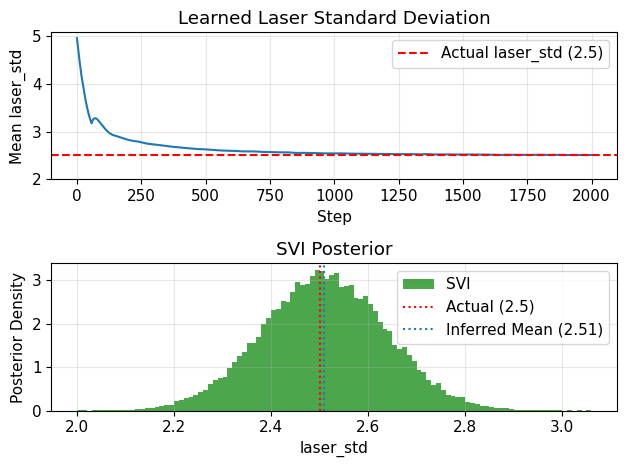

In [ ]:
# Plot the results
laser_std_samples = mcmc.get_samples()['laser_std']
plot_svi_inference(svi_losses, svi_means, svi_params, actual_laser_std=2.5)

In [ ]:
def plot_svi_convergence_laser(losses, means, actual_value=None,
                               param_label=r"$\theta_{\text{laser}}$"):
    """
    Convergence figure with consistent colors and professional styling.
    Colors: SVI Loss=black, SVI mean=steelblue, Simulations=red (matches other plots).
    """
    loss_arr = np.asarray(losses, dtype=float)
    mean_arr = np.asarray(means,  dtype=float)

    # Professional styling
    plt.style.use('default')
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 6))

    # Top: ELBO with BLACK styling
    ax0.plot(loss_arr, color="black", lw=1.5, alpha=0.8)
    ax0.set_title("SVI Loss Convergence (ELBO)", fontsize=13, pad=15)
    ax0.set_xlabel("Iteration", fontsize=11)
    ax0.set_ylabel("Loss", fontsize=11)
    ax0.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)

    # Bottom: mean trace
    ax1.plot(mean_arr, color="steelblue", lw=2, alpha=0.9, label="SVI posterior mean")

    if actual_value is not None:
        ax1.axhline(float(actual_value), color="red", linestyle="-", lw=2.5, alpha=0.9,
                    label=f"Value in simulations: {actual_value}")

    # Position text just above final mean value
    if len(mean_arr) > 0:
        final_mean = mean_arr[-1]
        final_iteration = len(mean_arr) - 1

        # Calculate offset as 3% of the y-range
        y_range = ax1.get_ylim()[1] - ax1.get_ylim()[0]
        y_offset = y_range * 0.03

        ax1.text(final_iteration, final_mean + y_offset,
                f'Final SVI: {final_mean:.3f}',
                ha='right', va='bottom', fontsize=9, alpha=0.7)

    ax1.set_title(f"Parameter Convergence: {param_label}", fontsize=13, pad=15)
    ax1.set_xlabel("Iteration", fontsize=11)
    ax1.set_ylabel("Posterior mean", fontsize=11)
    ax1.legend(loc="best", framealpha=0.95, fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig, (ax0, ax1)


def plot_posterior_histogram_laser(final_params, actual_value=None,
                                  param_label=r"$\theta_{\text{laser}}$", num_samples=40000,
                                  map_estimates=None, pg_samples=None):
    """
    Professional thesis-appropriate posterior histogram for LaserTag.
    Uses Normal distribution from mean/std parameters.
    Colors: SVI=steelblue, PG=orange overlay, MAP=green lines, Simulations=red.

    Parameters:
    -----------
    pg_samples : array-like, optional
        Particle Gibbs posterior samples to overlay. If None, no PG overlay.
    """
    # Extract SVI posterior parameters (Normal distribution)
    mu_svi = float(np.asarray(final_params["laser_std_mean"]))
    sigma_svi = float(np.asarray(final_params["laser_std_std"]))

    if sigma_svi <= 0:
        raise ValueError(f"Invalid SVI std for Normal: mean={mu_svi}, std={sigma_svi}")

    # Generate samples from Normal distribution
    svi_samples = np.random.normal(mu_svi, sigma_svi, int(num_samples))

    # Professional styling
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create x-axis for density curves based on 99.5% credible interval
    # This avoids cramped plots with too much empty space
    svi_ci_995 = np.percentile(svi_samples, [0.25, 99.75])
    ci_range = svi_ci_995[1] - svi_ci_995[0]
    x_min = svi_ci_995[0] - 0.3 * ci_range  # 30% padding on each side
    x_max = svi_ci_995[1] + 0.3 * ci_range

    # Adjust x-axis if PG samples provided
    if pg_samples is not None:
        pg_samples = np.array(pg_samples)
        pg_ci_995 = np.percentile(pg_samples, [0.25, 99.75])
        x_min = min(x_min, pg_ci_995[0] - 0.3 * (pg_ci_995[1] - pg_ci_995[0]))
        x_max = max(x_max, pg_ci_995[1] + 0.3 * (pg_ci_995[1] - pg_ci_995[0]))

    x = np.linspace(x_min, x_max, 200)

    # Compute and plot SVI density
    svi_kde = stats.gaussian_kde(svi_samples)
    svi_density = svi_kde(x)
    ax.fill_between(x, svi_density, alpha=0.3, color='steelblue', label='SVI posterior')
    ax.plot(x, svi_density, color='steelblue', linewidth=2)

    # Add PG posterior overlay if provided
    if pg_samples is not None:
        pg_kde = stats.gaussian_kde(pg_samples)
        pg_density = pg_kde(x)
        ax.fill_between(x, pg_density, alpha=0.2, color='orange', label='PG posterior')
        ax.plot(x, pg_density, color='orange', linewidth=2, linestyle='--')

        # PG statistics
        pg_mean = np.mean(pg_samples)
        pg_ci = np.percentile(pg_samples, [2.5, 97.5])
        ax.axvline(pg_mean, color='orange', linestyle=':', linewidth=2,
                   alpha=0.8, label=f'PG mean: {pg_mean:.3f}')

    # Add SVI vertical lines and credible intervals
    svi_mean = np.mean(svi_samples)
    svi_ci = np.percentile(svi_samples, [2.5, 97.5])

    ax.axvline(svi_mean, color='steelblue', linestyle='--', linewidth=2,
               alpha=0.8, label=f'SVI mean: {svi_mean:.3f}')
    ax.axvspan(svi_ci[0], svi_ci[1], alpha=0.1, color='steelblue')

    # Add MAP estimates if provided
    if map_estimates is not None:
        map_estimates = np.array(map_estimates)
        map_mean = np.mean(map_estimates)

        # Plot individual MAP estimates as thin vertical lines
        for i, estimate in enumerate(map_estimates):
            if i == 0:
                ax.axvline(estimate, color='green', linestyle='-', linewidth=1,
                          alpha=0.5, label='MAP estimates')
            else:
                ax.axvline(estimate, color='green', linestyle='-', linewidth=1,
                          alpha=0.5)

        # Plot MAP mean as thicker line
        ax.axvline(map_mean, color='green', linestyle='--', linewidth=2,
                   alpha=0.9, label=f'MAP mean: {map_mean:.3f}')

    # Add value in simulations line
    if actual_value is not None:
        ax.axvline(float(actual_value), color='red', linestyle='-', linewidth=2.5,
                   alpha=0.9, label=f'Value in simulations: {actual_value}')

    # Professional styling
    ax.set_xlabel(param_label, fontsize=12)
    ax.set_ylabel('Posterior density', fontsize=12)
    ax.set_title(f'Posterior Inference Results: {param_label}', fontsize=13, pad=20)
    ax.legend(loc='best', fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set axis limits with padding
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, None)

    plt.tight_layout()
    plt.show()

    # Enhanced numerical summary
    print("\n" + "="*60)
    print("POSTERIOR INFERENCE SUMMARY")
    print("="*60)
    print(f"{'Method':<12} {'Mean':<8} {'Std':<8} {'95% CI':<20} {'Mode':<8}")
    print("-" * 60)

    # SVI statistics
    svi_mode = x[np.argmax(svi_density)]
    print(f"{'SVI':<12} {svi_mean:<8.3f} {np.std(svi_samples):<8.3f} "
          f"[{svi_ci[0]:.3f}, {svi_ci[1]:.3f}] {svi_mode:<8.3f}")

    # PG statistics if provided
    if pg_samples is not None:
        pg_mean = np.mean(pg_samples)
        pg_std = np.std(pg_samples)
        pg_ci = np.percentile(pg_samples, [2.5, 97.5])
        pg_mode = x[np.argmax(pg_density)]
        print(f"{'PG':<12} {pg_mean:<8.3f} {pg_std:<8.3f} "
              f"[{pg_ci[0]:.3f}, {pg_ci[1]:.3f}] {pg_mode:<8.3f}")

    # MAP statistics if provided
    if map_estimates is not None:
        map_estimates = np.array(map_estimates)
        map_mean = np.mean(map_estimates)
        map_std = np.std(map_estimates)
        map_ci = np.percentile(map_estimates, [2.5, 97.5])
        print(f"{'MAP':<12} {map_mean:<8.3f} {map_std:<8.3f} "
              f"[{map_ci[0]:.3f}, {map_ci[1]:.3f}] {'N/A':<8}")

    # Normal distribution properties
    print(f"\nNormal Distribution Parameters (SVI):")
    print(f"  Mean (μ): {mu_svi:.3f}")
    print(f"  Std (σ): {sigma_svi:.3f}")
    print(f"  Variance (σ²): {sigma_svi**2:.3f}")

    if actual_value is not None:
        sim_val = float(actual_value)
        svi_error = abs(svi_mean - sim_val)
        print(f"\nValue in Simulations Comparison:")
        print(f"  Simulation value: {sim_val:.3f}")
        print(f"  SVI error:  {svi_error:.4f}")

        if pg_samples is not None:
            pg_error = abs(pg_mean - sim_val)
            print(f"  PG error:   {pg_error:.4f}")

        if map_estimates is not None:
            map_error = abs(map_mean - sim_val)
            print(f"  MAP error:  {map_error:.4f}")

        print(f"  Relative error: {(svi_error/sim_val*100):.2f}%")
        print(f"  Value in 95% CI: {'Yes' if svi_ci[0] <= sim_val <= svi_ci[1] else 'No'}")

    print("="*60)

    return fig, ax

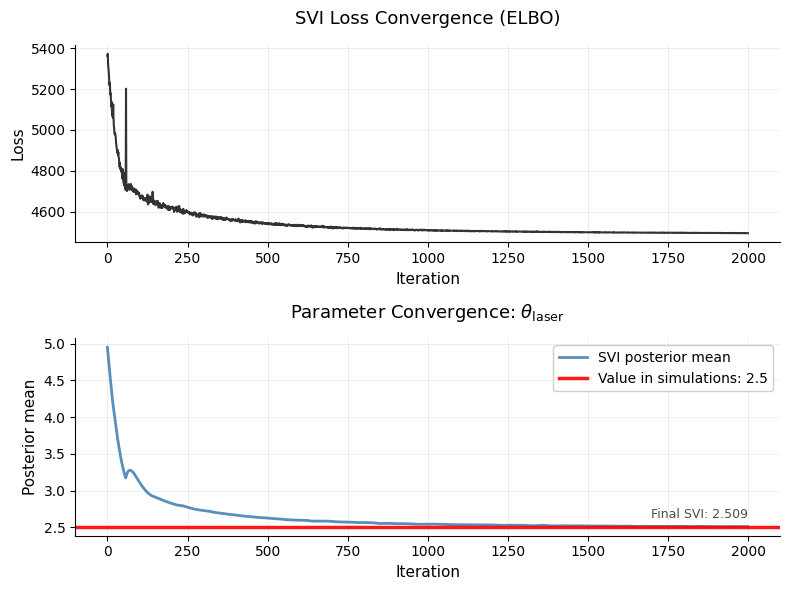

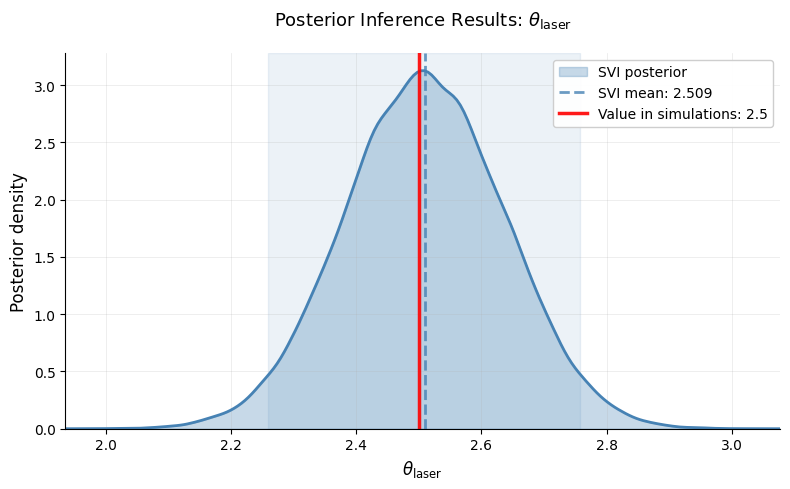


POSTERIOR INFERENCE SUMMARY
Method       Mean     Std      95% CI               Mode    
------------------------------------------------------------
SVI          2.509    0.127    [2.260, 2.758] 2.509   

Normal Distribution Parameters (SVI):
  Mean (μ): 2.509
  Std (σ): 0.128
  Variance (σ²): 0.016

Value in Simulations Comparison:
  Simulation value: 2.500
  SVI error:  0.0092
  Relative error: 0.37%
  Value in 95% CI: Yes


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Inference Results: $\\theta_{\\text{laser}}$'}, xlabel='$\\theta_{\\text{laser}}$', ylabel='Posterior density'>)

In [ ]:
plot_svi_convergence_laser(
    svi_losses, svi_means,
    actual_value=2.5,
    param_label=r"$\theta_{\text{laser}}$"
)

plot_posterior_histogram_laser(
    svi_params,
    actual_value=2.5,
    param_label=r"$\theta_{\text{laser}}$",
    num_samples=40000
)

# Baseline

## EM


Benchmarking LaserTag POMDP SVI Inference...
Configuration: 2000 iterations, 10 independent runs
Running timing benchmark...
----------------------------------------
Run  1/10: Running SVI inference...
 32.29s
Run  2/10: Running SVI inference...
 31.89s
Run  3/10: Running SVI inference...
 31.37s
Run  4/10: Running SVI inference...
 31.46s
Run  5/10: Running SVI inference...
 31.34s
Run  6/10: Running SVI inference...
 32.47s
Run  7/10: Running SVI inference...
 31.12s
Run  8/10: Running SVI inference...
 33.04s
Run  9/10: Running SVI inference...
 33.90s
Run 10/10: Running SVI inference...
 32.98s
----------------------------------------
LASERTAG POMDP TIMING RESULTS
----------------------------------------
Mean ± Std:   32.19 ±  0.87 seconds
Median:       32.09 seconds
Range:       [31.12, 33.90] seconds
Per iteration:  16.1 ms/iteration
----------------------------------------


/tmp/ipython-input-3661370117.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([times], labels=['LaserTag SVI'])


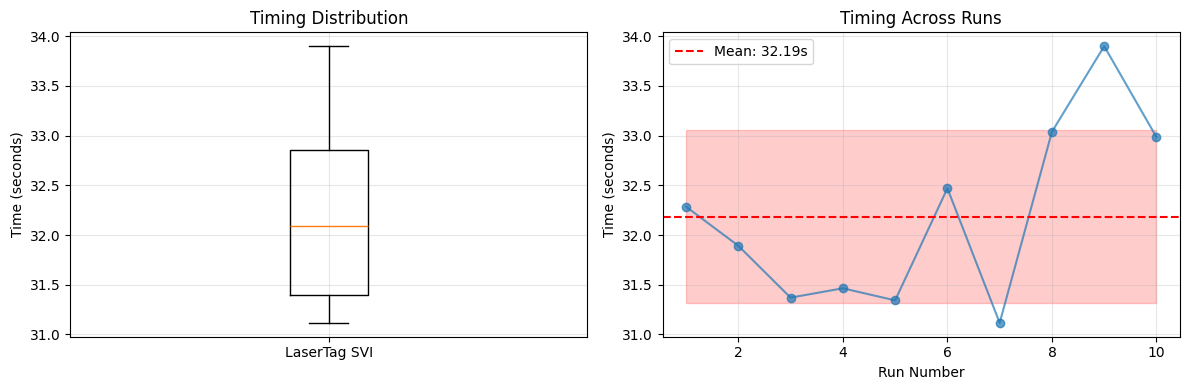

In [ ]:
def benchmark_lasertag_svi(svi_inference_func, data, model, num_steps=2000, num_runs=10):

    print(f"\nBenchmarking LaserTag POMDP SVI Inference...")
    print(f"Configuration: {num_steps} iterations, {num_runs} independent runs")
    print(f"Running timing benchmark...")
    print("-" * 40)

    times = []

    for run in range(num_runs):
        print(f"Run {run+1:2d}/{num_runs}: ", end="", flush=True)

        # Clear JAX caches for consistent timing
        jax.clear_caches()

        # Time the inference
        start_time = time.time()

        # Call your SVI inference function with LaserTag signature
        svi_losses, svi_means, svi_params = svi_inference_func(data, model, num_steps)

        end_time = time.time()

        run_time = end_time - start_time
        times.append(run_time)

        print(f"{run_time:6.2f}s")

    times = np.array(times)

    # Calculate statistics
    stats = {
        'mean': np.mean(times),
        'std': np.std(times),
        'min': np.min(times),
        'max': np.max(times),
        'median': np.median(times),
        'times': times,
        'num_steps': num_steps,
        'num_runs': num_runs
    }

    # Print results
    print("-" * 40)
    print("LASERTAG POMDP TIMING RESULTS")
    print("-" * 40)
    print(f"Mean ± Std:  {stats['mean']:6.2f} ± {stats['std']:5.2f} seconds")
    print(f"Median:      {stats['median']:6.2f} seconds")
    print(f"Range:       [{stats['min']:5.2f}, {stats['max']:5.2f}] seconds")
    print(f"Per iteration: {stats['mean']/num_steps*1000:5.1f} ms/iteration")
    print("-" * 40)

    return stats

def plot_timing_results(stats):
    """Plot timing results for analysis."""
    import matplotlib.pyplot as plt

    times = stats['times']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Box plot
    ax1.boxplot([times], labels=['LaserTag SVI'])
    ax1.set_ylabel('Time (seconds)')
    ax1.set_title('Timing Distribution')
    ax1.grid(True, alpha=0.3)

    # Time series
    ax2.plot(range(1, len(times)+1), times, 'o-', alpha=0.7)
    ax2.axhline(np.mean(times), color='red', linestyle='--',
                label=f'Mean: {np.mean(times):.2f}s')
    ax2.fill_between(range(1, len(times)+1),
                     np.mean(times) - np.std(times),
                     np.mean(times) + np.std(times),
                     alpha=0.2, color='red')
    ax2.set_xlabel('Run Number')
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Timing Across Runs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Usage:
lasertag_stats = benchmark_lasertag_svi(
    svi_inference_func=svi_inference,
    data=data_no_opponent,
    model=laser_model_svi,
    num_steps=2000,
    num_runs=10
)

# Optional: Plot the results
plot_timing_results(lasertag_stats)

In [ ]:
def sample_trajectories_laser(data, n_samples=100):
    all_episode_trajectories = []

    for episode in data['episodes']:
        episode_trajectories = []
        for _ in range(n_samples):
            # Use existing generate_trajectories but for single episode
            single_episode_data = {
                'episodes': [episode],
                'obstacles': data['obstacles']
            }
            trajectory = generate_trajectories(single_episode_data)[0]
            episode_trajectories.append(trajectory)
        all_episode_trajectories.append(episode_trajectories)

    return all_episode_trajectories


def compute_trajectory_weights_laser(episode, trajectories, laser_std):
    log_ws = []
    for traj in trajectories:
        lp = logprob_laser_episode(laser_std, traj, episode['observations'])
        log_ws.append(float(lp))

    log_ws = np.asarray(log_ws, dtype=np.float64)

    if not np.isfinite(log_ws).any():
        return np.ones_like(log_ws) / len(log_ws)

    m = np.max(log_ws)
    ws = np.exp(log_ws - m)
    s = ws.sum()
    if s <= 1e-300:
        return np.ones_like(ws) / len(ws)
    else:
        w = ws / s
        return w / w.sum()


def select_multiple_trajectories_laser(trajectories, weights, k=5):
    """Select top K trajectories based on weights"""
    top_indices = np.argsort(weights)[-k:]
    selected_trajs = [trajectories[i] for i in top_indices]
    selected_weights = weights[top_indices]
    selected_weights = selected_weights / selected_weights.sum()
    return selected_trajs, selected_weights


def em_algorithm(data, n_samples=20, max_iterations=20, k_trajectories=1, show_prints=True):
    laser_std = np.random.uniform(1.0, 5.0)
    history = [laser_std]

    if show_prints:
        print(f"EM with MAP: sampling {n_samples} trajectories, using top {k_trajectories} per episode")

    # Sample trajectories once
    all_trajectories = sample_trajectories_laser(data, n_samples)

    converged = False

    for iteration in range(max_iterations):
        if show_prints:
            print(f"\nIteration {iteration + 1}: laser_std = {laser_std:.4f}")

        # E-step: reweight trajectories
        all_weights = []
        for episode, trajs in zip(data['episodes'], all_trajectories):
            weights = compute_trajectory_weights_laser(episode, trajs, laser_std)
            all_weights.append(weights)

        # Select top K trajectories per episode
        selected_trajectories = []
        selected_weights = []
        for trajs, weights in zip(all_trajectories, all_weights):
            sel_trajs, sel_weights = select_multiple_trajectories_laser(trajs, weights, k_trajectories)
            selected_trajectories.append(sel_trajs)
            selected_weights.append(sel_weights)

        # M-step: weighted MAP estimation
        def neg_log_likelihood(std):
            if std <= 0.01:
                return 1e10

            total = 0.0
            for episode, trajs, weights in zip(data['episodes'], selected_trajectories, selected_weights):
                episode_ll = 0.0
                for traj, weight in zip(trajs, weights):
                    episode_ll += weight * logprob_laser_episode(std, traj, episode['observations'])
                total += episode_ll

            # Add prior: Exponential(0.2)
            prior_ll = np.log(0.2) - 0.2 * std
            return -(total + prior_ll)

        from scipy.optimize import minimize_scalar
        result = minimize_scalar(neg_log_likelihood, bounds=(laser_std*0.5, laser_std*2), method='bounded')
        new_laser_std = result.x

        if show_prints:
            print(f"  New laser_std: {new_laser_std:.4f}")
            print(f"  Change: {abs(new_laser_std - laser_std):.6f}")

        if abs(new_laser_std - laser_std) < 1e-4:
            print(f"Converged after {iteration + 1} iterations")
            converged = True
            break

        laser_std = new_laser_std
        history.append(laser_std)

    if not converged:
        print("Did not converge.")

        print(f"Last value: {history[-1]:.4f}")

    return history

EM with MAP: sampling 20 trajectories, using top 1 per episode

Iteration 1: laser_std = 2.6487
  New laser_std: 2.4617
  Change: 0.187037

Iteration 2: laser_std = 2.4617
  New laser_std: 2.4604
  Change: 0.001294

Iteration 3: laser_std = 2.4604
  New laser_std: 2.4618
  Change: 0.001346

Iteration 4: laser_std = 2.4618
  New laser_std: 2.4617
  Change: 0.000011
Converged after 4 iterations

Results:
MAP:  2.4618


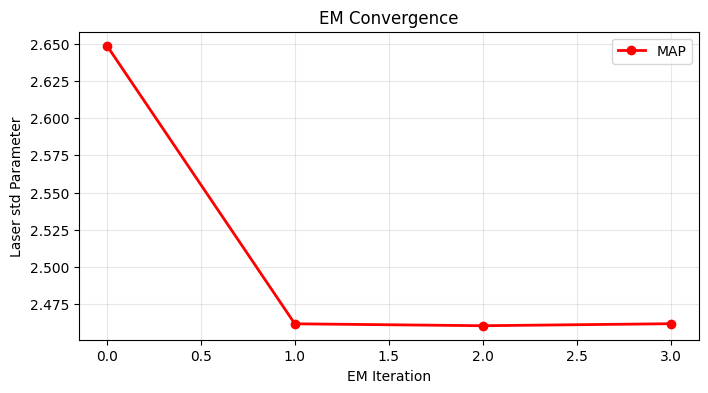

In [ ]:
map_history = em_algorithm(data_no_opponent)

print(f"\nResults:")
print(f"MAP:  {map_history[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(map_history, 'r-o', label='MAP', linewidth=2)
plt.xlabel('EM Iteration')
plt.ylabel('Laser std Parameter')
plt.title('EM Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
map_estimates = []
n_iterations = 10

for run in range(n_iterations):
    print(f"Run {run+1}/{n_iterations}")
    history = em_algorithm(data_no_opponent, show_prints=False)
    map_estimates.append(history[-1])

map_estimates = np.array(map_estimates)

Run 1/10
Converged after 4 iterations
Run 2/10
Converged after 6 iterations
Run 3/10
Converged after 2 iterations
Run 4/10
Converged after 11 iterations
Run 5/10
Converged after 7 iterations
Run 6/10
Converged after 13 iterations
Run 7/10
Converged after 6 iterations
Run 8/10
Converged after 15 iterations
Run 9/10
Converged after 5 iterations
Run 10/10
Converged after 3 iterations


In [ ]:
svi_losses, svi_means, svi_params = svi_inference(data_no_opponent, laser_model_svi, num_steps=2000)

Running SVI inference...


## Particle MCMC

In [ ]:
def csmc(particles, retained=None):
    """Conditional SMC. When retained is None, unconditional. Arguments:
        * particles - vector of particles
        * retained - steps of retained particle (at index 0)
    """
    steps = [[] for _ in particles]

    while not particles[0].done:
        for particle in particles:
            particle.step()
        if retained is not None:
            particles[0] = retained.pop(0)
        for i in range(len(particles)):
            steps[i].append(copy(particles[i]))
        indices = np.random.choice(
            len(particles), size=len(particles),
            p=softmax([particle.log_prob for particle in particles]))
        particles = [particles[i].renew() for i in indices]

    for particle in particles:
        assert particle.done, "not all particles terminated at the same time"

    retained = steps[random.randint(0, len(steps) - 1)]
    return particles, retained


def pgibbs(mkparticle, nparticles, niter, collect=None):
    """Particle MCMC (Gibbs) loop.
    """
    retained = None
    for iter in tqdm.trange(niter):
        particles = [mkparticle() for _ in range(nparticles)]
        particles, retained = csmc(particles, retained)
        if collect is not None:
            collect(particles)
    return particles

In [ ]:
class Particle():
    def __init__(self, log_prob=0):
        self.log_prob = log_prob
        self.done = False

    def step(self):
        pass

    def renew(self):
        particle = copy(self)
        particle.log_prob = 0
        return particle

In [ ]:
class LaserTagParticle(Particle):
    def __init__(self, data, log_prob=0):
        super().__init__(log_prob)

        self.obstacles = set(data['obstacles'])
        self.grid = (11, 7)

        # Convert episodes to step-by-step format similar to RockSample logs
        # Each episode becomes a list of (state, observation) tuples
        self.episodes = [[]]  # sentinel
        for episode in data['episodes']:
            episode_steps = []
            for i in range(len(episode['states'])):
                episode_steps.append({
                    'state': episode['states'][i],
                    'observation': episode['observations'][i]
                })
            self.episodes.append(episode_steps)

        # Sample laser_std from prior (Exponential(0.2))
        self.laser_std = np.random.exponential(scale=1/0.2)

    def step(self):
        episode, episodes = self.episodes[0], self.episodes[1:]

        if not episode:
            # Remove finished episode, start new one
            self.episodes = self.episodes[1:]
            episode, episodes = self.episodes[0], self.episodes[1:]

            # Initialize new episode
            initial_state = episode[0]['state']
            self.robot_pos = initial_state[0]
            if initial_state[1] is not None:
                self.opponent_pos = initial_state[1]
            else:
                self.opponent_pos = (np.random.randint(1, self.grid[0] + 1),
                                    np.random.randint(1, self.grid[1] + 1))

        # Get current step and remaining steps
        step_data, episode = episode[0], episode[1:]

        # Check if last step of last episode
        if not episode and not episodes:
            self.done = True

        # Update episodes list
        self.episodes = [episode] + episodes

        # Process step
        state = step_data['state']
        observation = step_data['observation']

        self.robot_pos = state[0]
        terminal = state[2]

        # Calculate log probability for this observation
        if not terminal and observation is not None:
            step_logp = self._compute_step_logprob(
                self.robot_pos, self.opponent_pos, observation, self.laser_std
            )
            self.log_prob += step_logp

        # Sample opponent's next position (if not terminal and more steps remain)
        if not terminal and episode:
            self.opponent_pos = apply_stochastic_opponent_movement(
                self.robot_pos, self.opponent_pos, self.obstacles
            )

    def _compute_step_logprob(self, robot_pos, opponent_pos, observation, laser_std):
        """
        Compute log probability for a single observation step.
        """
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0), (1, 1), (1, -1), (-1, -1), (-1, 1)]

        if robot_pos == opponent_pos:
            return 0.0

        if observation is None or np.any(np.array(observation) < 0):
            return 0.0

        all_true_distances = []
        all_observed = []

        for direction_idx, (dx, dy) in enumerate(directions):
            # Calculate clear cells
            distance = 0
            x, y = robot_pos
            while True:
                x += dx
                y += dy
                distance += 1
                if x < 1 or x > self.grid[0] or y < 1 or y > self.grid[1]:
                    break
                if (x, y) == opponent_pos:
                    break

            clear_cells = distance - 1
            observed_distance = observation[direction_idx]

            # Calculate true distance
            if direction_idx < 4:  # Cardinal
                true_distance = clear_cells + 1
            else:  # Diagonal
                true_distance = (clear_cells + 1) * np.sqrt(2)

            all_true_distances.append(true_distance)
            all_observed.append(observed_distance)

        all_true_distances = np.array(all_true_distances)
        all_observed = np.array(all_observed)

        # abs_noise ~ HalfNormal(laser_std)
        abs_noise_values = all_true_distances - all_observed

        # Calculate log probability using HalfNormal
        valid_noise = abs_noise_values >= 0
        if not np.any(valid_noise):
            return -1e10

        valid_abs_noise = abs_noise_values[valid_noise]
        log_probs = (np.log(2) - 0.5 * np.log(2 * np.pi * laser_std**2) -
                    (valid_abs_noise**2) / (2 * laser_std**2))

        return np.sum(log_probs)


def run_particle_gibbs_laser(data, nparticles=100, niter=100):
    mkparticle = lambda: LaserTagParticle(data)

    laser_stds = []

    def collect(particles):
        laser_stds.extend([p.laser_std for p in particles])

    pgibbs(mkparticle, nparticles, niter=niter, collect=collect)

    return np.array(laser_stds)

100%|██████████| 100/100 [1:05:17<00:00, 39.17s/it]


Mean: 2.527, Std: 0.065


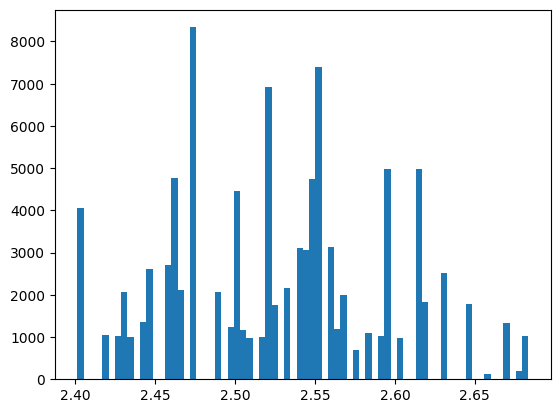

In [ ]:
NPARTICLES = 1000
NITER = 100

laser_stds = run_particle_gibbs_laser(data_no_opponent, nparticles=NPARTICLES, niter=NITER)
plt.hist(laser_stds, bins='auto')
print(f"Mean: {laser_stds.mean():.3f}, Std: {laser_stds.std():.3f}")

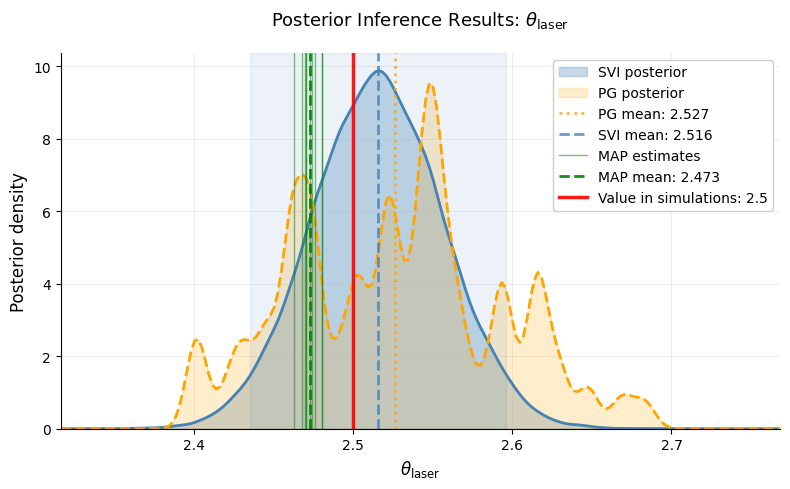


POSTERIOR INFERENCE SUMMARY
Method       Mean     Std      95% CI               Mode    
------------------------------------------------------------
SVI          2.516    0.041    [2.436, 2.596] 2.516   
PG           2.527    0.065    [2.402, 2.669] 2.548   
MAP          2.473    0.005    [2.464, 2.481] N/A     

Normal Distribution Parameters (SVI):
  Mean (μ): 2.516
  Std (σ): 0.041
  Variance (σ²): 0.002

Value in Simulations Comparison:
  Simulation value: 2.500
  SVI error:  0.0155
  PG error:   0.0265
  MAP error:  0.0272
  Relative error: 0.62%
  Value in 95% CI: Yes


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Inference Results: $\\theta_{\\text{laser}}$'}, xlabel='$\\theta_{\\text{laser}}$', ylabel='Posterior density'>)

In [ ]:
plot_posterior_histogram_laser(
    svi_params,
    actual_value=2.5,
    map_estimates=map_estimates,
    pg_samples=laser_stds
)

In [ ]:
def model_vectorized(data):
    """Bayesian model for laser_std inference"""
    laser_std = numpyro.sample('laser_std', dist.Exponential(0.2))

    episodes = data['episodes']
    n_episodes = len(episodes)

    with numpyro.plate('n_episodes', n_episodes):
        episode_logprobs = []
        for episode in episodes:
            states = episode['states']
            observations = episode['observations']
            episode_logp = logprob_laser_episode(laser_std, states, observations)
            episode_logprobs.append(episode_logp)

        episode_logprobs = jnp.array(episode_logprobs)
        numpyro.factor('episodes', jnp.sum(episode_logprobs))